# Week 6 Interim Deliverable — Baseline Triage Models

**Author:** Varune  
**Dataset:** Yale EMMLC ED triage (cleaned, Week 5)

This notebook trains and evaluates two baseline classifiers — Logistic Regression and a Decision Tree — to predict Emergency Severity Index (ESI 1–5), and compares them against a stratified random baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries loaded. ✅


**My notes:** Loading libraries up front, including the specific `sklearn.metrics` functions (`classification_report`, `f1_score`, `recall_score`) I'll need later for per-class evaluation, not just overall accuracy.

## 1 · Load the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv')
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Mounted at /content/drive
Loaded 55121 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**My notes:** This is the same cleaned dataset from Week 5 (55,121 encounters, 226 columns). I'm loading it from Drive so the notebook is reproducible without re-uploading the file each session.

## 2 · Choose the features (X) and the target (y)

In [3]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

In [4]:
X = df[FEATURES]     # the clues
y = df[TARGET]       # the answer

print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:6], "...")

Model will use 209 features to predict: esi
First few features: ['Unnamed: 0', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2'] ...


**My notes:** The target is `esi`. I split candidate columns into vitals, demographics, and admin/other features so I can be deliberate about what the model is and isn't allowed to see — for example, keeping out any column that would only be known *after* triage, which would leak the answer into the features.

## 3 · Split into training and test sets

In [5]:
#Split the data is 20% for judgement and 80% for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025


**My notes:** I stratified the split on `esi` so the rare ESI 1 patients are still represented in roughly the same proportion in both the training and test sets. Without stratification, a random split could put most ESI 1 patients on one side, which would make my recall numbers later unreliable. `random_state=42` makes the split reproducible if this notebook is re-run.

## 4 · A baseline to beat (DummyClassifier)

In [6]:
#A model that only guesses.

dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)

print("Dummy baseline accuracy:", round(dummy.score(X_test, y_test), 3))

Dummy baseline accuracy: 0.375


**My notes:** This dummy model doesn't look at a patient's vitals at all — it just guesses ESI levels in the same proportions as the training data. It's my “coin flip” reference point: any real model has to beat this, especially on recall for ESI 1, before I can call it useful.

## 5 · Model 1 — Logistic Regression

In [7]:
#Train Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)

print("Logistic Regression accuracy:", round(logreg.score(X_test_s, y_test), 3))

Logistic Regression accuracy: 0.667


**My notes:** I standardized the features with `StandardScaler` before fitting. Logistic Regression is sensitive to the scale of its inputs — without scaling, a feature like heart rate (values in the hundreds) would dominate a feature like temperature (values around 37) just because its numbers are bigger, not because it's more clinically important.

## 6 · Model 2 — Decision Tree

In [8]:
#Training the Decision Tree
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

print("Decision Tree accuracy:", round(tree.score(X_test, y_test), 3))

Decision Tree accuracy: 0.556


**My notes:** I capped `max_depth` at 5 on purpose. With so few ESI 1 examples in the data, a deeper tree risks memorizing quirks of the training set (overfitting) rather than learning a pattern that generalizes to new patients.

## 7 · Visualise how each model decides

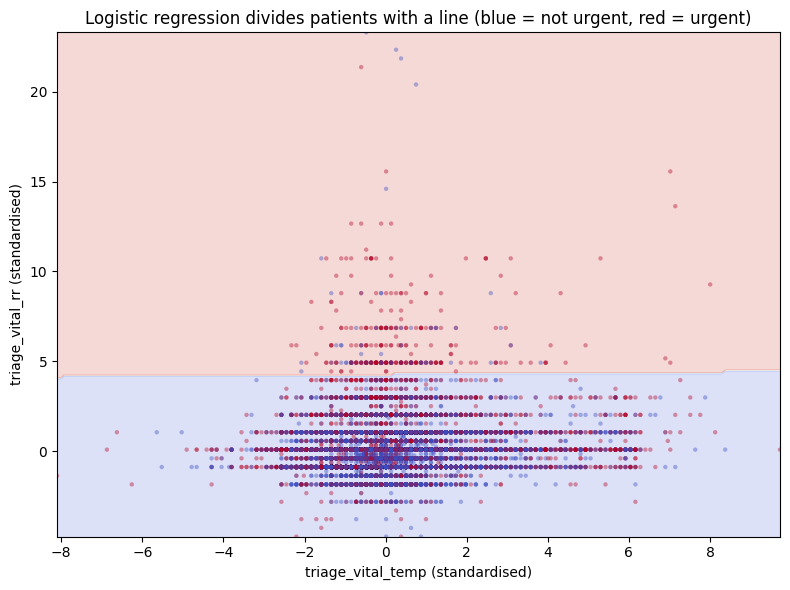

In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import os

#f1, f2 = "triage_vital_o2", "triage_vital_rr"
f1, f2 = "triage_vital_temp", "triage_vital_rr"

urgent = (y <= 2).astype(int)          # 1 = urgent, 0 = not urgent

two = StandardScaler().fit_transform(X[[f1, f2]])

demo = LogisticRegression(max_iter=1000).fit(two, urgent)

xx, yy = np.meshgrid(np.linspace(two[:, 0].min(), two[:, 0].max(), 200),
                     np.linspace(two[:, 1].min(), two[:, 1].max(), 200))
zz = demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")                 # the two decision regions
ax.scatter(two[:, 0], two[:, 1], c=urgent, cmap="coolwarm",
           s=10, alpha=0.4, edgecolor="none")                      # the patients
ax.set_xlabel(f1 + " (standardised)")
ax.set_ylabel(f2 + " (standardised)")
ax.set_title("Logistic regression divides patients with a line (blue = not urgent, red = urgent)")
plt.tight_layout()
os.makedirs("figs", exist_ok=True) # Create the directory if it doesn't exist
plt.savefig("figs/w6_logreg_boundary.png", dpi=120, bbox_inches="tight")
plt.show()

A flowchart view of the trained Decision Tree, and its top splits in text form:

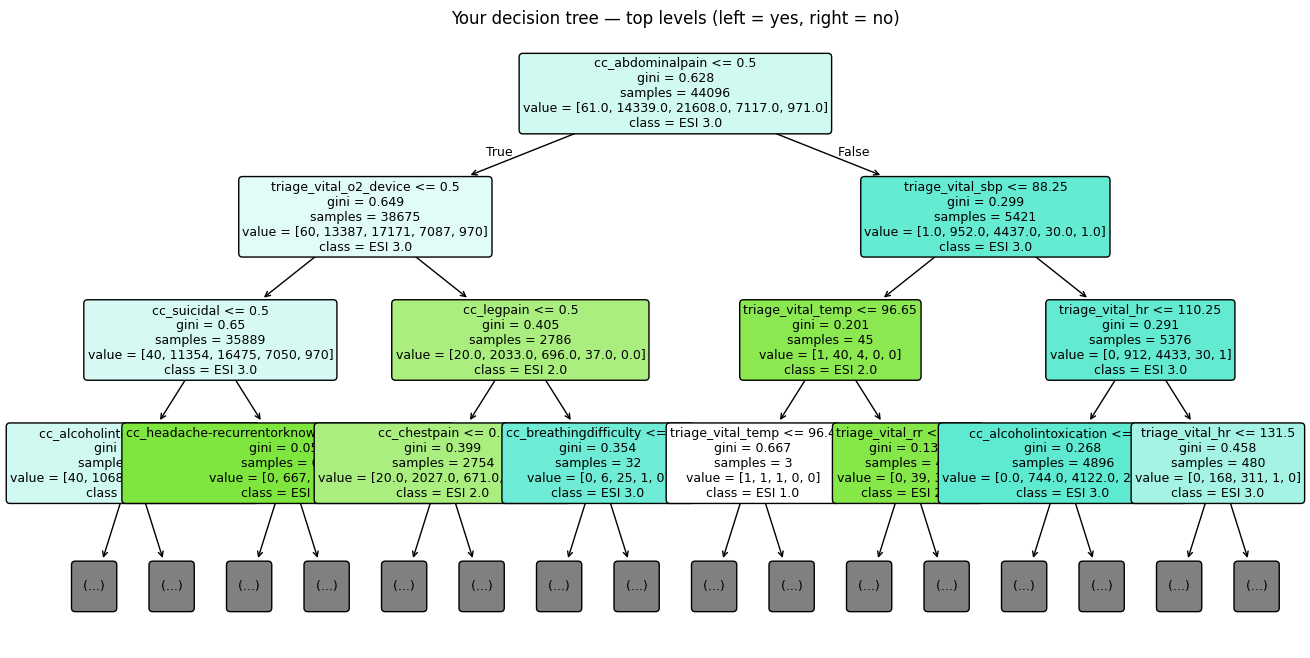

In [10]:
#Flowchart of my trained tree
from sklearn.tree import plot_tree
import os

os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=[f"ESI {c}" for c in tree.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
ax.set_title("Your decision tree — top levels (left = yes, right = no)")
plt.savefig("figs/w6_decision_tree.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
from sklearn.tree import export_text
print(export_text(tree, feature_names=list(FEATURES), max_depth=3))

|--- cc_abdominalpain <= 0.50
|   |--- triage_vital_o2_device <= 0.50
|   |   |--- cc_suicidal <= 0.50
|   |   |   |--- cc_alcoholintoxication <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_alcoholintoxication >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cc_suicidal >  0.50
|   |   |   |--- cc_headache-recurrentorknowndxmigraines <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_headache-recurrentorknowndxmigraines >  0.50
|   |   |   |   |--- class: 3.0
|   |--- triage_vital_o2_device >  0.50
|   |   |--- cc_legpain <= 0.50
|   |   |   |--- cc_chestpain <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_chestpain >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cc_legpain >  0.50
|   |   |   |--- cc_breathingdifficulty <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_breathingdifficulty >  0.50
|   |   |   |   |--- class: 2.0
|---

## 8 · Save the trained models

In [12]:
#Save the models for later use

joblib.dump(logreg, "model_logreg.joblib")
joblib.dump(tree,   "model_tree.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅")

Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅


**My notes:** Saving the fitted models and scaler with `joblib` means they can be reloaded later without retraining — useful if I want to reuse them in a separate script or app.

---
# Part 2 — Model Evaluation

Both baselines are trained. Now I evaluate them with metrics that matter for triage, not just accuracy, since ESI 1 is only about 0.1% of the dataset.

## 9 · Make predictions on the test set

In [13]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: gets each model's predicted ESI for the test set.
# Both later confusion matrices, classification reports, and the
# benchmark table all depend on these two variables existing.
# ------------------------------------------------------------------
pred_logreg = logreg.predict(X_test_s)   # scaled features for LR
pred_tree   = tree.predict(X_test)       # unscaled for the tree
print("Example predictions (logreg):", pred_logreg[:10])

Example predictions (logreg): [2. 3. 3. 2. 2. 2. 3. 3. 3. 2.]


**My notes:** This cell was missing from my earlier draft — `pred_logreg` and `pred_tree` need to exist before anything below can run. Making predictions explicit here (rather than inline in each metric cell) means the whole notebook can be re-run top to bottom without errors, which matters if Dr. Reyes wants to reproduce my results himself.

## 10 · Confusion matrices

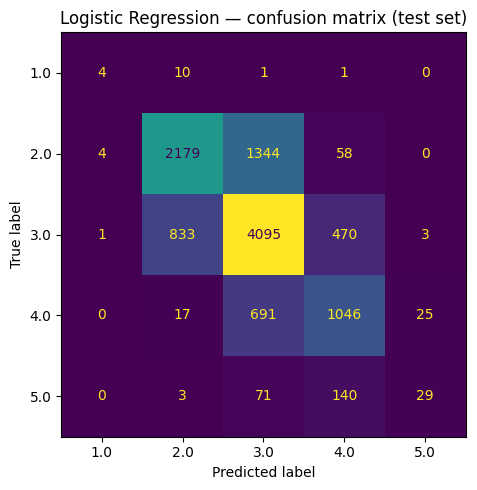

In [14]:
#Confusion Matrix for the Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False)
ax.set_title("Logistic Regression — confusion matrix (test set)")
plt.tight_layout()
plt.show()

*I'm also plotting the Decision Tree's confusion matrix, not just Logistic Regression's, so I can compare where each model's mistakes land before deciding which is the stronger baseline.*

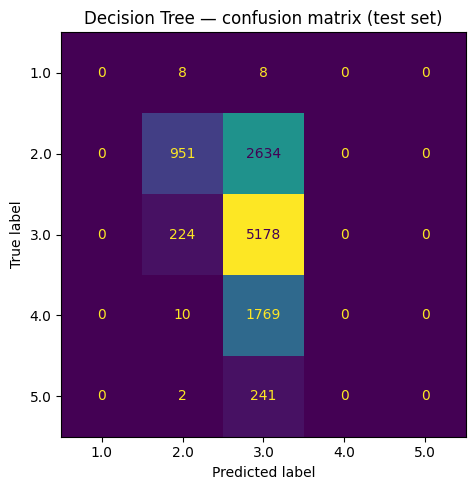

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, ax=ax, colorbar=False)
ax.set_title("Decision Tree — confusion matrix (test set)")
plt.tight_layout()
plt.show()

## 11 · Per-class metrics (classification_report)

Accuracy alone hides how a model performs on the rare, critical classes. `classification_report` gives precision, recall, and F1 for every ESI level individually, for both models.

In [16]:
# WHAT THIS CELL DOES: prints precision / recall / F1 for EACH ESI level,
print("Logistic Regression\n" + "-"*21)
print(classification_report(y_test, pred_logreg, digits=3))

print("Decision Tree\n" + "-"*13)
print(classification_report(y_test, pred_tree, digits=3))

Logistic Regression
---------------------
              precision    recall  f1-score   support

         1.0      0.444     0.250     0.320        16
         2.0      0.716     0.608     0.658      3585
         3.0      0.660     0.758     0.706      5402
         4.0      0.610     0.588     0.599      1779
         5.0      0.509     0.119     0.193       243

    accuracy                          0.667     11025
   macro avg      0.588     0.465     0.495     11025
weighted avg      0.667     0.667     0.661     11025

Decision Tree
-------------
              precision    recall  f1-score   support

         1.0      0.000     0.000     0.000        16
         2.0      0.796     0.265     0.398      3585
         3.0      0.527     0.959     0.680      5402
         4.0      0.000     0.000     0.000      1779
         5.0      0.000     0.000     0.000       243

    accuracy                          0.556     11025
   macro avg      0.265     0.245     0.216     11025
weighte

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**My notes:** This is the cell my supervisor flagged — I had imported `classification_report` but never actually called it. Running it for both models side by side is what shows the ESI 1 and ESI 5 rows clearly, which the single accuracy number completely hides.

## 12 · Macro vs weighted F1

In [17]:
# compares the two ways of averaging F1.
# macro = every ESI level counts equally; weighted = big classes dominate.

macro_f1 = f1_score(y_test, pred_logreg, average="macro")
weighted_f1 = f1_score(y_test, pred_logreg, average="weighted")

print("Macro F1:   ", round(macro_f1, 3))
print("Weighted F1:", round(weighted_f1, 3))

Macro F1:    0.495
Weighted F1: 0.661


**My notes:** Macro F1 treats every ESI level equally; weighted F1 lets the big classes (ESI 2/3) dominate. The gap between the two (0.495 vs 0.661 for Logistic Regression) is itself informative — it shows how much weighted F1 is being propped up by strong performance on the common classes alone.

## 13 · The number that matters most: recall for ESI 1

In [18]:
# extracts recall for ESI level 1 for each model.

recall_logreg_esi1 = recall_score(y_test, pred_logreg, labels=[1], average=None)[0]
recall_tree_esi1 = recall_score(y_test, tree.predict(X_test), labels=[1], average=None)[0]

print("Recall for ESI 1 — Logistic Regression:", round(recall_logreg_esi1, 3))
print("Recall for ESI 1 — Decision Tree:      ", round(recall_tree_esi1, 3))

Recall for ESI 1 — Logistic Regression: 0.25
Recall for ESI 1 — Decision Tree:       0.0


**My notes:** This is my primary metric. Recall for ESI 1 answers one specific question: of the patients who truly needed immediate resuscitation, how many did the model actually catch? Logistic Regression catches 1 in 4. The Decision Tree catches **zero** — despite reasonable overall accuracy, it never once flags a truly critical patient in the test set.

## 14 · Compare the models at a glance

In [19]:
#Comparison between the two models and the Dummy model

def summarise(name, preds):
    return {
        "model": name,
        "accuracy": round((preds == y_test).mean(), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro"), 3),
        "recall_ESI1": round(recall_score(y_test, preds, labels=[1], average=None)[0], 3),
    }

table = pd.DataFrame([
    summarise("Dummy (baseline)", dummy.predict(X_test)),
    summarise("Logistic Regression", pred_logreg),
    summarise("Decision Tree", tree.predict(X_test)),
])
table

,model,accuracy,macro_F1,recall_ESI1
0,Dummy (baseline),0.375,0.204,0.00
1,Logistic Regression,0.667,0.495,0.25
2,Decision Tree,0.556,0.216,0.00


**My notes:** Logistic Regression is the stronger baseline overall — it beats the Decision Tree on accuracy, macro F1, and recall for ESI 1. The Decision Tree's 0.00 recall on ESI 1 is the most important number in this table: it would be invisible if I only reported accuracy, which is exactly why accuracy isn't my primary metric.

## 15 · Save the confusion-matrix figure

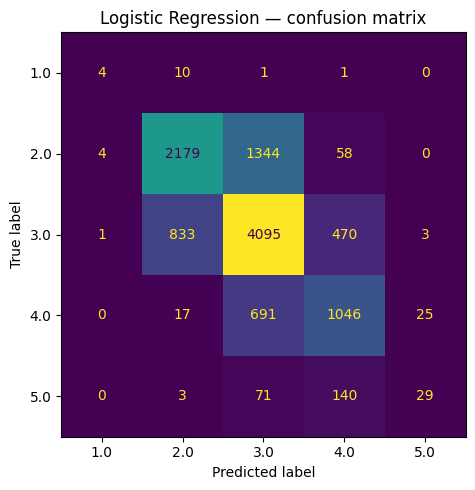

Saved figs/w6_confusion_logreg.png ✅


In [20]:
#save the confusion matrix
import os
os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False)
ax.set_title("Logistic Regression — confusion matrix")
plt.tight_layout()
plt.savefig("figs/w6_confusion_logreg.png", dpi=110)
plt.show()
print("Saved figs/w6_confusion_logreg.png ✅")